<a href="https://colab.research.google.com/github/wtryab-re/classification/blob/main/Basic_Classification_Pipeline.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Install and Import

In [ ]:
!pip install -q scikit-learn matplotlib numpy pandas seaborn

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_curve, roc_auc_score, precision_recall_curve, auc, f1_score, precision_score, recall_score

In [ ]:
og_df = pd.read_csv("diabetes.csv")
og_df.shape

(768, 9)

In [ ]:
df = og_df.copy()

In [ ]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [ ]:
df.columns

Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'],
      dtype='object')

#Data Quality Checks

In [ ]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


#Missing Values = 0

High Zeros Check

#Duplicates

In [ ]:
df.duplicated().sum()

np.int64(0)

#Data Type Validation

In [ ]:
df.dtypes

,0
Pregnancies,int64
Glucose,int64
BloodPressure,int64
SkinThickness,int64
Insulin,int64
BMI,float64
DiabetesPedigreeFunction,float64
Age,int64
Outcome,int64


#Constant Columns

In [ ]:
constant_cols = []
quasi_constant_cols = []
id_like_cols =[]
for col in df.columns:
  if df[col].nunique() == 1:
    constant_cols.append(col)
  elif df[col].value_counts(normalize=True).max() > 0.9:
    quasi_constant_cols.append(col)
  elif df[col].nunique() == df.shape[0]:
    id_like_cols.append(col)

print(f"Constant Columns: {constant_cols}")
print(f"Quasi Constant Columns: {quasi_constant_cols}")
print(f"ID Like Columns: {id_like_cols}")

Constant Columns: []
Quasi Constant Columns: []
ID Like Columns: []


In [ ]:
X = df.drop("Outcome", axis=1)
y=df["Outcome"]

#Train Test Split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((614, 8), (154, 8), (614,), (154,))

#Scale

In [ ]:
scaler = StandardScaler()

In [ ]:
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

#Handle Missing Values but there are none

In [ ]:
df.columns

Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'],
      dtype='object')

In [ ]:
cat_cols = []
num_cols= df.columns.to_list()
num_cols.remove("Outcome")
num_cols

['Pregnancies',
 'Glucose',
 'BloodPressure',
 'SkinThickness',
 'Insulin',
 'BMI',
 'DiabetesPedigreeFunction',
 'Age']

#Outlier Detection

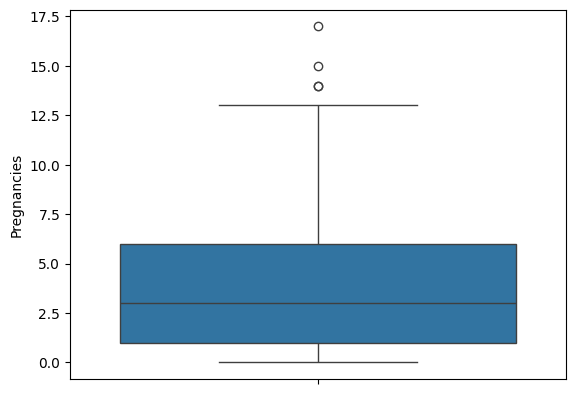

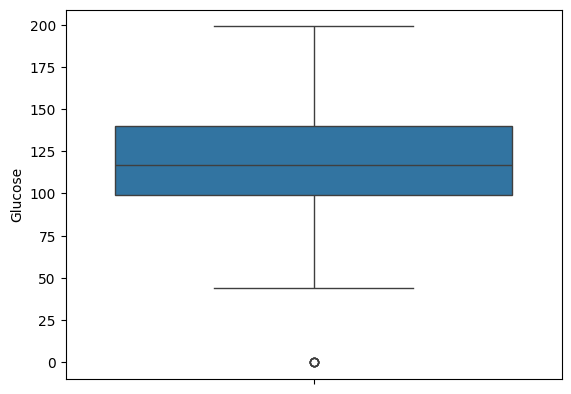

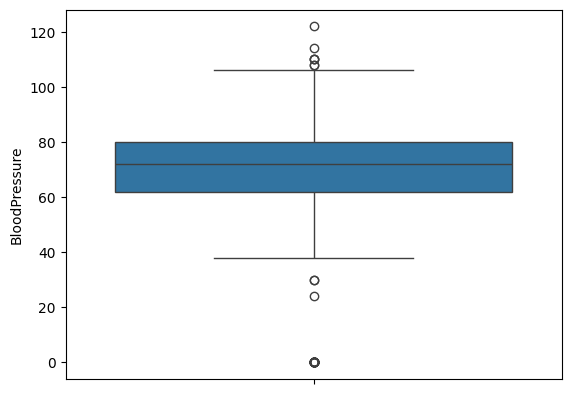

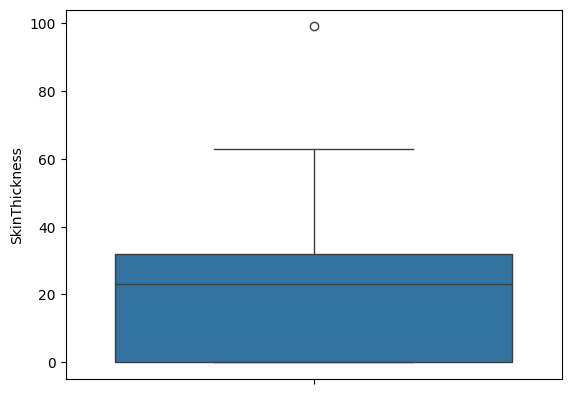

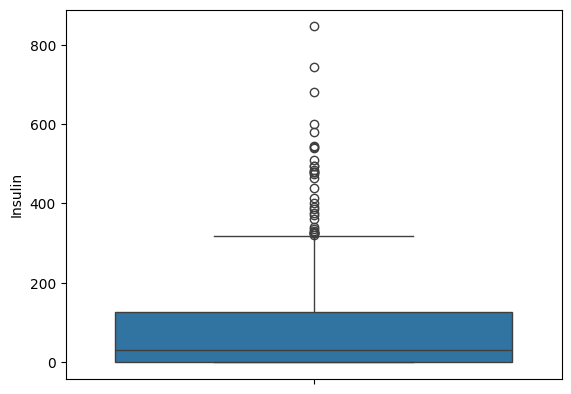

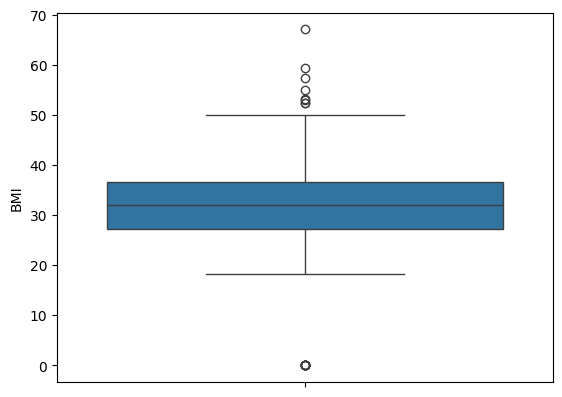

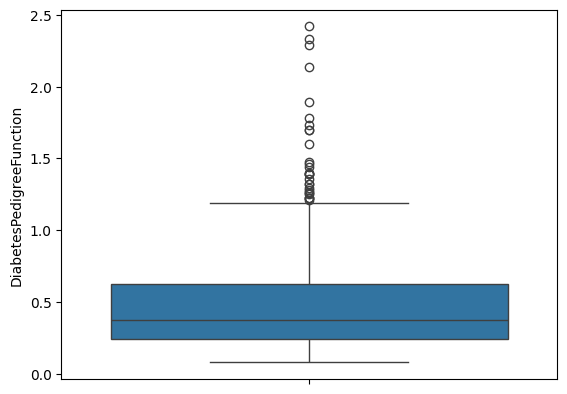

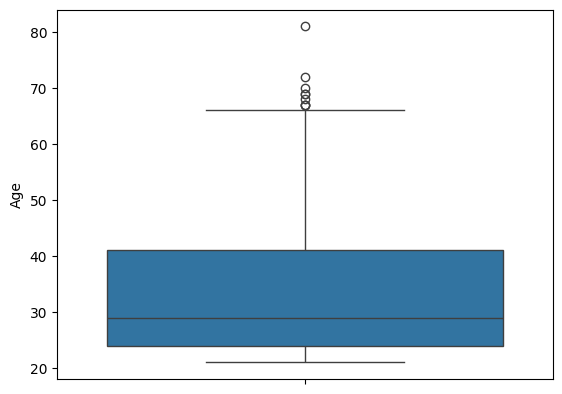

In [ ]:
for cols in num_cols:
  sns.boxplot(df[cols])
  plt.show()
  print()

#Model training without outlier removal

In [ ]:
model = LogisticRegression()
model.fit(X_train_scaled, y_train)
y_test_predictions = model.predict(X_test_scaled)
y_train_predictions = model.predict(X_train_scaled)
y_pred_probs = model.predict_proba(X_test_scaled)

##Train data evaluation metrics

In [ ]:
print("Accuracy: ",accuracy_score(y_train, y_train_predictions))
print("Precision: ",precision_score(y_train, y_train_predictions))
print("Recall: ",recall_score(y_train, y_train_predictions))
print("F1 Score: ",f1_score(y_train, y_train_predictions))
print("ROC AUC Score: ",roc_auc_score(y_train, y_train_predictions))
print(confusion_matrix(y_train, y_train_predictions))

Accuracy:  0.7915309446254072
Precision:  0.7590361445783133
Recall:  0.5887850467289719
F1 Score:  0.6631578947368421
ROC AUC Score:  0.744392523364486
[[360  40]
 [ 88 126]]


##Test data evaluation Metrics

In [ ]:
print("Accuracy: ", accuracy_score(y_test, y_test_predictions))
print("Precision: ", precision_score(y_test, y_test_predictions, zero_division=0))
print("Recall: ", recall_score(y_test, y_test_predictions, zero_division=0))
print("F1 Score: ", f1_score(y_test, y_test_predictions, zero_division=0))
print("ROC AUC Score: ", roc_auc_score(y_test, y_test_predictions))
print(confusion_matrix(y_test, y_test_predictions))

Accuracy:  0.7142857142857143
Precision:  0.6086956521739131
Recall:  0.5185185185185185
F1 Score:  0.56
ROC AUC Score:  0.6692592592592593
[[82 18]
 [26 28]]


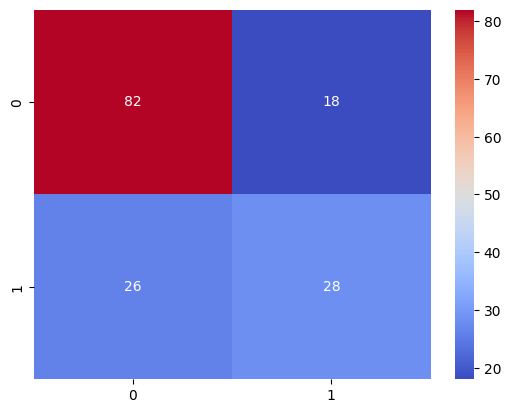

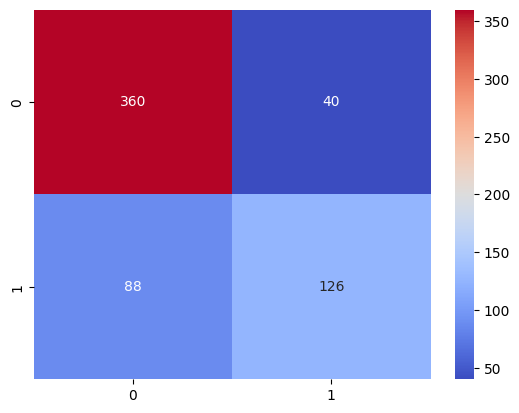

In [ ]:
sns.heatmap(confusion_matrix(y_test, y_test_predictions), annot=True, fmt='d', cmap = "coolwarm")
plt.show()

sns.heatmap(confusion_matrix(y_train, y_train_predictions), annot=True, fmt='d', cmap = "coolwarm")
plt.show()

Text(0, 0.5, 'True Positive Rate')

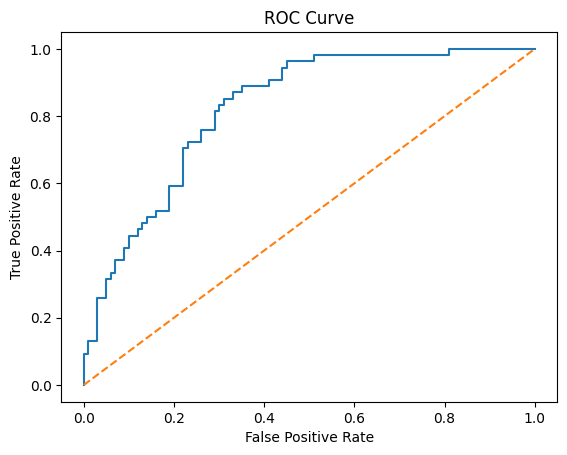

In [ ]:
false_pos_r, true_pos_r, thresholds= roc_curve(y_test, y_pred_probs[:,1])
auc = roc_auc_score(y_test, y_test_predictions)
plt.plot(false_pos_r, true_pos_r)
plt.plot([0,1], [0,1], linestyle="--")
plt.title("ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

#Model training after outlier removal